In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [40]:

def plot_front_view(can_file, slice_idx=64, slice_plane='zx'):
    """
    Parses a streaming EllipSys .CAN file format and plots a cross-section.
    
    Parameters:
    - can_file: Path to the .CAN file
    - slice_idx: The grid index along the perpendicular axis to cut through (0 to 127)
    - slice_plane: 'zx' (longitudinal cut along Y) or 'zy' (lateral cut along X)
    """
    # 1. Parse header information
    with open(can_file, 'r') as f:
        header1 = f.readline().split()
        header2 = f.readline().split()
        
        # Stream the remaining text content cleanly
        data_tokens = f.read().split()

    nx, ny = int(header1[0]), int(header1[1])
    x_min, x_max, y_min, y_max = map(float, header2)

    # Convert all streamed numeric tokens to a flat float array
    data_stream = np.array(data_tokens, dtype=float)
    
    # 2. Reconstruct the 3D PAD Grid from the stream
    nz_max = 19  
    pad_3d = np.zeros((nx, ny, nz_max))
    
    stream_ptr = 0
    for i in range(nx):
        for j in range(ny):
            h_val = data_stream[stream_ptr]
            
            if h_val <= 1.00:
                # Open corridor cell (no canopy profile)
                stream_ptr += 2
            else:
                # Canopy/forest cell containing 19 vertical layers
                profile_pads = data_stream[stream_ptr + 1 : stream_ptr + 1 + nz_max]
                pad_3d[i, j, :] = profile_pads
                stream_ptr += (1 + nz_max + 1)

    # 3. Build spatial axes coordinates
    x_coords = np.linspace(x_min, x_max, nx)
    y_coords = np.linspace(y_min, y_max, ny)
    z_coords = np.linspace(0, 20.0, nz_max)

    # 4. Extract the slice and generate the plot
    # Increasing height slightly to ensure 1-meter tick labels are legible and un-crowded
    plt.figure(figsize=(10, 8))
    
    if slice_plane.lower() == 'zx':
        # Side profile: Longitudinal cut along a constant Y
        cross_section = pad_3d[:, slice_idx, :].T  # Transpose to [z, x]
        horiz_coords = x_coords
        plt.title(f'ZX Canopy Cross-Section')
        plt.xlabel('Distance Along Corridor (x) [m]')
        
        # Automatically find tree boundaries along the X axis to focus on the corridor
        tree_presence_x = np.sum(pad_3d, axis=(1, 2))
        x_indices_with_trees = np.where(tree_presence_x > 0)[0]
        if len(x_indices_with_trees) > 0:
            # Crop to outer tree boundaries minus/plus 20 meters
            xmin_crop = max(x_min, x_coords[x_indices_with_trees[0]] - 20.0)
            xmax_crop = min(x_max, x_coords[x_indices_with_trees[-1]] + 20.0)
            plt.xlim(xmin_crop, xmax_crop)
            
    else:
        # Front profile: Lateral cut along a constant X
        cross_section = pad_3d[slice_idx, :, :].T  # Transpose to [z, y]
        horiz_coords = y_coords
        plt.title(f'ZY Canopy Cross-Section')
        plt.xlabel('Lateral Cross-Distance (y) [m]')

    # Plot using pcolormesh
    im = plt.pcolormesh(horiz_coords, z_coords, cross_section, cmap='Greens', shading='auto')
    
    # Formatting Layout
    plt.colorbar(im, label='PAD [m²/m³]')
    plt.ylabel('Height (z) [m]')
    
    # Force y-axis limit and set explicit tick spacing for every 1 meter
    plt.ylim(0, 21)
    plt.yticks(np.arange(0, 21, 5))  # Major ticks every 5m
    
    # Optional faint horizontal gridline helper to make meter reading easy
    # plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # increasing text size
    text_size = 14
    plt.title(plt.gca().get_title(), fontsize=text_size + 2)
    plt.xlabel(plt.gca().get_xlabel(), fontsize=text_size)
    plt.ylabel(plt.gca().get_ylabel(), fontsize=text_size)
    plt.tick_params(axis='both', which='major', labelsize=text_size - 2)


    plt.tight_layout()
    
    outfile = f'Corridor_{slice_plane.upper()}_corr60_View.png'
    # plt.savefig(outfile, dpi=300)
    print(f"Success! Slice saved as {outfile}")
    plt.show()


Success! Slice saved as Corridor_ZX_corr60_View.png


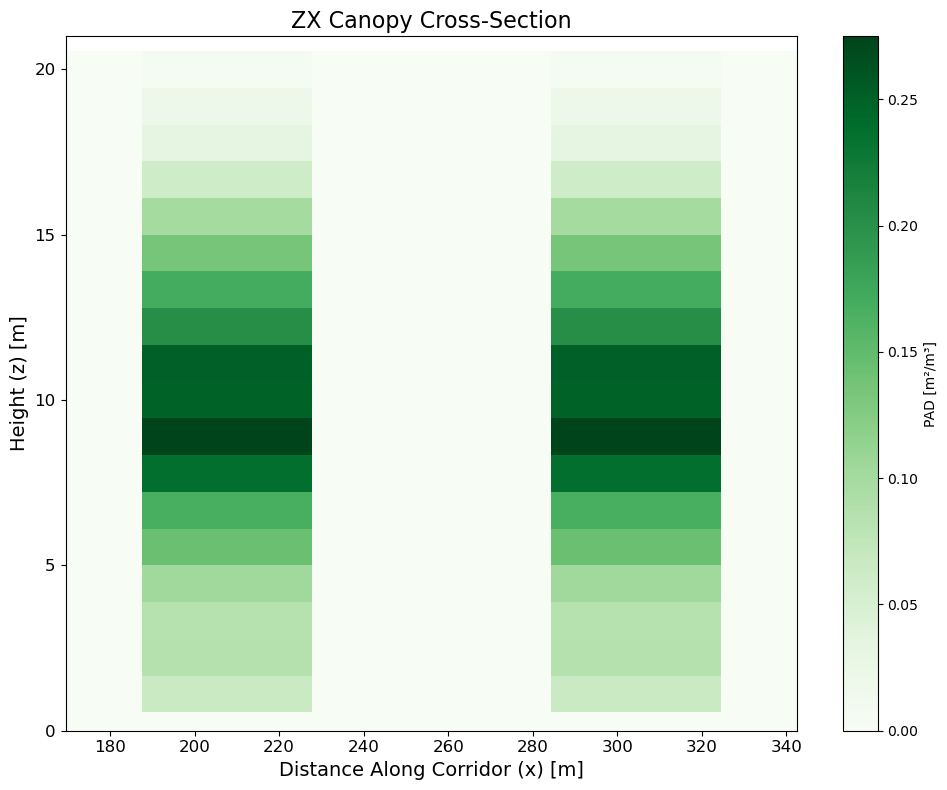

In [41]:

if __name__ == "__main__":
    # slice_idx=64 cuts directly through the middle of your 128x128 grid
    plot_front_view('corridor_4dx_512m_corr60.CAN', slice_idx=64, slice_plane='zx')